In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
import joblib
import streamlit as st
import warnings
warnings.filterwarnings("ignore")

In [3]:
df=pd.read_csv("AmesHousing.csv")

In [4]:
df.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [5]:
df.shape

(2930, 82)

In [6]:
df.describe()

,Order,PID,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,...,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice
count,2930.00000,2.930000e+03,2930.000000,2440.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2907.000000,...,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000
mean,1465.50000,7.144645e+08,57.387372,69.224590,10147.921843,6.094881,5.563140,1971.356314,1984.266553,101.896801,...,93.751877,47.533447,23.011604,2.592491,16.002048,2.243345,50.635154,6.216041,2007.790444,180796.060068
std,845.96247,1.887308e+08,42.638025,23.365335,7880.017759,1.411026,1.111537,30.245361,20.860286,179.112611,...,126.361562,67.483400,64.139059,25.141331,56.087370,35.597181,566.344288,2.714492,1.316613,79886.692357
min,1.00000,5.263011e+08,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,12789.000000
25%,733.25000,5.284770e+08,20.000000,58.000000,7440.250000,5.000000,5.000000,1954.000000,1965.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,2007.000000,129500.000000
50%,1465.50000,5.354536e+08,50.000000,68.000000,9436.500000,6.000000,5.000000,1973.000000,1993.000000,0.000000,...,0.000000,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,160000.000000
75%,2197.75000,9.071811e+08,70.000000,80.000000,11555.250000,7.000000,6.000000,2001.000000,2004.000000,164.000000,...,168.000000,70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,213500.000000
max,2930.00000,1.007100e+09,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,...,1424.000000,742.000000,1012.000000,508.000000,576.000000,800.000000,17000.000000,12.000000,2010.000000,755000.000000


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   object 
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   object 
 7   Alley            198 non-null    object 
 8   Lot Shape        2930 non-null   object 
 9   Land Contour     2930 non-null   object 
 10  Utilities        2930 non-null   object 
 11  Lot Config       2930 non-null   object 
 12  Land Slope       2930 non-null   object 
 13  Neighborhood     2930 non-null   object 
 14  Condition 1      2930 non-null   object 
 15  Condition 2      2930 non-null   object 
 16  Bldg Type        2930 non-null   object 
 17  House Style   

In [8]:
df.shape

(2930, 82)

In [9]:
df.isnull().sum()

Order               0
PID                 0
MS SubClass         0
MS Zoning           0
Lot Frontage      490
                 ... 
Mo Sold             0
Yr Sold             0
Sale Type           0
Sale Condition      0
SalePrice           0
Length: 82, dtype: int64

In [10]:
df.duplicated().sum()

0

In [11]:
df["SalePrice"].describe()

count      2930.000000
mean     180796.060068
std       79886.692357
min       12789.000000
25%      129500.000000
50%      160000.000000
75%      213500.000000
max      755000.000000
Name: SalePrice, dtype: float64

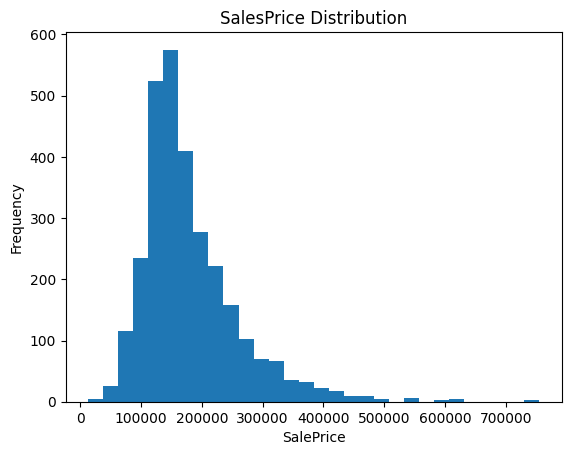

In [12]:
plt.figure(figure=(8,5))
plt.hist(df["SalePrice"],bins=30)
plt.title("SalesPrice Distribution")
plt.xlabel("SalePrice")
plt.ylabel("Frequency")
plt.show()

In [13]:
corr = df.select_dtypes(include=np.number).corr()
corr["SalePrice"].sort_values(ascending=False).head(20)

SalePrice         1.000000
Overall Qual      0.799262
Gr Liv Area       0.706780
Garage Cars       0.647877
Garage Area       0.640401
Total Bsmt SF     0.632280
1st Flr SF        0.621676
Year Built        0.558426
Full Bath         0.545604
Year Remod/Add    0.532974
Garage Yr Blt     0.526965
Mas Vnr Area      0.508285
TotRms AbvGrd     0.495474
Fireplaces        0.474558
BsmtFin SF 1      0.432914
Lot Frontage      0.357318
Wood Deck SF      0.327143
Open Porch SF     0.312951
Half Bath         0.285056
Bsmt Full Bath    0.276050
Name: SalePrice, dtype: float64

In [14]:
corr["SalePrice"].sort_values(ascending=False)[1:11]

Overall Qual      0.799262
Gr Liv Area       0.706780
Garage Cars       0.647877
Garage Area       0.640401
Total Bsmt SF     0.632280
1st Flr SF        0.621676
Year Built        0.558426
Full Bath         0.545604
Year Remod/Add    0.532974
Garage Yr Blt     0.526965
Name: SalePrice, dtype: float64

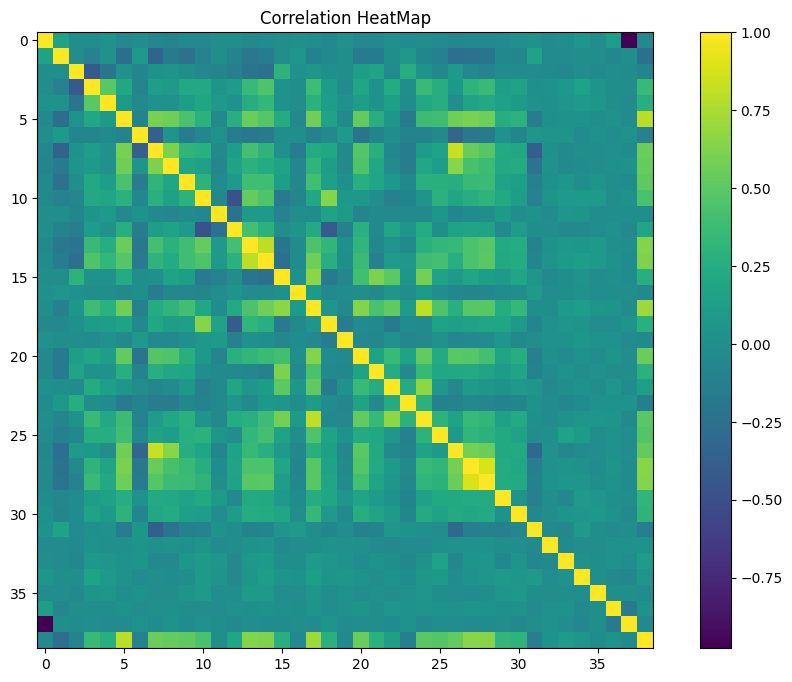

In [15]:
corr=df.select_dtypes(include=np.number).corr()
plt.figure(figsize=(12,8))
plt.imshow(corr)
plt.colorbar()
plt.title("Correlation HeatMap")
plt.show()

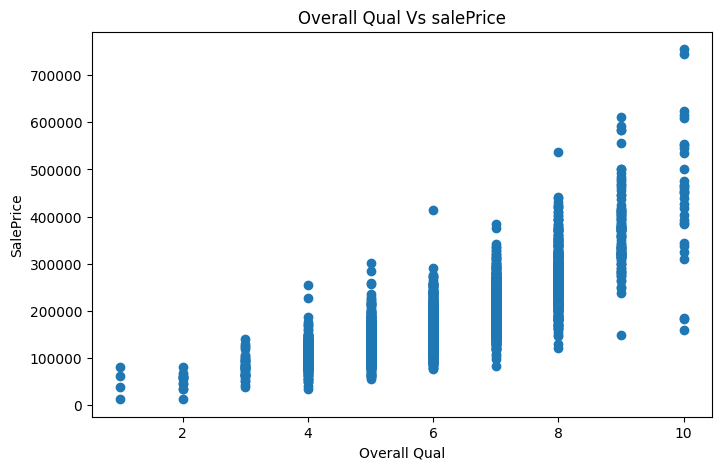

In [16]:
plt.figure(figsize=(8,5))
plt.scatter(df["Overall Qual"],df["SalePrice"])
plt.xlabel("Overall Qual")
plt.ylabel("SalePrice")
plt.title("Overall Qual Vs salePrice")
plt.show()

In [17]:
x=df.drop("SalePrice",axis=1)
y=df["SalePrice"]

In [18]:
num_cols=x.select_dtypes(include=["int64","float64"]).columns

In [19]:
cat_cols=x.select_dtypes(include=["object","category"]).columns

In [20]:
num_pipeline=Pipeline(steps=([
    ("imputer",SimpleImputer(strategy="median")),
    ("scaler",StandardScaler())
]))

In [21]:
cat_pipeline=Pipeline(steps=([
    ("imputer",SimpleImputer(strategy="most_frequent")),
    ("encoder",OneHotEncoder(handle_unknown="ignore"))
]))

In [22]:
preprocessor=ColumnTransformer(transformers=([
    ("nums",num_pipeline,num_cols),
    ("cat",cat_pipeline,cat_cols)
]))

In [23]:
model_lr=Pipeline(steps=[
    ("preprocessor",preprocessor),
    ("regression",LinearRegression())
])

In [24]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [25]:
model_lr.fit(x_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('nums',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['Order', 'PID', 'MS SubClass', 'Lot Frontage', 'Lot Area',
       'Overall Qual', 'Overall Cond', 'Year Built', 'Year Remod/Add',
       'Mas Vnr Area', 'BsmtFin SF 1', 'BsmtFin SF 2', 'Bsmt Unf SF',
       'Total Bsmt SF', '1st Flr S...
       'Exter Cond', 'Foundation', 'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure',
       'BsmtFin Type 1', 'BsmtFin Type 2', 'Heating', 'Heating QC',
       'Central Air', 'Electrical', 'Kitchen Qual', 'Functional',
       'Fireplace Qu', 'Garage Type', 'Garage Finish', 'Garage Qual',
       'Garage Cond', 'Paved Drive', 'Pool QC', 'Fence', 'Misc Feature',
       'Sale Type', 'Sale Condition'],
      dtype='object'))])),
                ('regression', LinearRegression())])

In [26]:
y_pred_1 = model_lr.predict(x_test)

In [27]:
mae=mean_absolute_error(y_pred_1,y_test)
print("Mean absolute error:- ",mae)

Mean absolute error:-  16034.181607658355


In [28]:
mse=mean_squared_error(y_pred_1,y_test)
print("Mean squared_error:- ",mse)

Mean squared_error:-  878258556.9493924


In [29]:
rmse =mean_squared_error(y_pred_1,y_test,squared=False)
print("RMSE-: ",rmse)

RMSE-:  29635.42739609794


In [30]:
r2 = r2_score(y_pred_1,y_test)
print("r2_score:- ",r2)

r2_score:-  0.8828111070054944


In [31]:
cv_score_1=cross_val_score(model_lr,x,y,cv=5,scoring="r2")
print("Cross validation Score r2:- ",cv_score_1.mean())

Cross validation Score r2:-  0.8587273758588946


In [32]:
model_rf = Pipeline([
    ("preprocessor",preprocessor),
    ("model",RandomForestRegressor(n_estimators=300,max_depth=20,random_state=42,n_jobs=-1))
])

In [33]:
model_rf.fit(x_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('nums',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['Order', 'PID', 'MS SubClass', 'Lot Frontage', 'Lot Area',
       'Overall Qual', 'Overall Cond', 'Year Built', 'Year Remod/Add',
       'Mas Vnr Area', 'BsmtFin SF 1', 'BsmtFin SF 2', 'Bsmt Unf SF',
       'Total Bsmt SF', '1st Flr S...
       'BsmtFin Type 1', 'BsmtFin Type 2', 'Heating', 'Heating QC',
       'Central Air', 'Electrical', 'Kitchen Qual', 'Functional',
       'Fireplace Qu', 'Garage Type', 'Garage Finish', 'Garage Qual',
       'Garage Cond', 'Paved Drive', 'Pool QC', 'Fence', 'Misc Feature',
       'Sale Type', 'Sale Condition'],
      dtype='object'))])),
                ('model',
                 RandomForestRegressor(max_depth=20, n_estimators=300,
                                       n_jobs=-1, random_state=42))])

In [34]:
y_pred_2=model_rf.predict(x_test)

In [35]:
mae=mean_squared_error(y_pred_2,y_test)
print("Mean absolute error:- ",mae)

Mean absolute error:-  710623623.608851


In [36]:
mse=mean_squared_error(y_pred_2,y_test)
print("Mean squared error:- ",mse)

Mean squared error:-  710623623.608851


In [37]:
rmse =mean_squared_error(y_pred_2,y_test,squared=False)
print("RMSE-: ",rmse)

RMSE-:  26657.524708960715


In [38]:
r2 = r2_score(y_pred_2,y_test)
print("r2_score:- ",r2)

r2_score:-  0.8917222877165679


In [39]:
cv_score_2=cross_val_score(model_rf,x,y,cv=5,scoring="r2")
print("Cross validation score 2:- ",cv_score_2.mean())

Cross validation score 2:-  0.8865669895522104


In [40]:
gb_model=Pipeline(steps=([
    ("preprocessor",preprocessor),
    ("model",GradientBoostingRegressor(n_estimators=300,learning_rate=0.05,max_depth=4,random_state=42))
]))

In [41]:
gb_model.fit(x_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('nums',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['Order', 'PID', 'MS SubClass', 'Lot Frontage', 'Lot Area',
       'Overall Qual', 'Overall Cond', 'Year Built', 'Year Remod/Add',
       'Mas Vnr Area', 'BsmtFin SF 1', 'BsmtFin SF 2', 'Bsmt Unf SF',
       'Total Bsmt SF', '1st Flr S...
       'BsmtFin Type 1', 'BsmtFin Type 2', 'Heating', 'Heating QC',
       'Central Air', 'Electrical', 'Kitchen Qual', 'Functional',
       'Fireplace Qu', 'Garage Type', 'Garage Finish', 'Garage Qual',
       'Garage Cond', 'Paved Drive', 'Pool QC', 'Fence', 'Misc Feature',
       'Sale Type', 'Sale Condition'],
      dtype='object'))])),
                ('model',
                 GradientBoostingRegressor(learning_rate=0.05, max_depth=4,
                                           n_estimators=300,
                                           random_state=42))])

In [42]:
y_pred_3=gb_model.predict(x_test)

In [43]:
mae=mean_absolute_error(y_pred_3,y_test)
print("Mean absolute error:- ",mae)

Mean absolute error:-  14180.128280239702


In [44]:
mse=mean_squared_error(y_pred_3,y_test)
print("Mean squqred error:- ",mse)

Mean squqred error:-  586217396.0389073


In [45]:
rmse =mean_squared_error(y_pred_3,y_test,squared=False)
print("RMSE-: ",rmse)

RMSE-:  24211.926731239448


In [46]:
r2 = r2_score(y_pred_3,y_test)
print("r2_score:- ",r2)

r2_score:-  0.9181843242925665


In [47]:
cv_score_gb=cross_val_score(gb_model,x,y,cv=5,scoring="r2")
print("Cross validation score:- ",cv_score_gb.mean())

Cross validation score:-  0.9077537817109059


In [48]:
gb = gb_model.named_steps["model"]
feature_names=gb_model.named_steps[
    "preprocessor"
].get_feature_names_out()
importance=pd.DataFrame({
    "Feature":feature_names,
    "Importance":gb.feature_importances_
})
importance.sort_values("Importance",ascending=False).head(20)

,Feature,Importance
5,nums__Overall Qual,0.552718
17,nums__Gr Liv Area,0.113865
27,nums__Garage Cars,0.043482
14,nums__1st Flr SF,0.035730
7,nums__Year Built,0.029599
10,nums__BsmtFin SF 1,0.026251
13,nums__Total Bsmt SF,0.024797
15,nums__2nd Flr SF,0.022813
4,nums__Lot Area,0.016919
20,nums__Full Bath,0.011980


In [49]:
joblib.dump(model_rf,"house_price_model.joblib",compress=3)

['house_price_model.joblib']

In [50]:
model=joblib.load("house_price_model.joblib")
print("Model loaded successfully")

Model loaded successfully


In [51]:
%%writefile app_1.py
import streamlit as st
import joblib 
import pandas as pd
model=joblib.load("house_price_model.joblib")
st.set_page_config(page_title="House Price Preidction")
st.title("house Price Prediction")
st.write("Upload a csv file and predict house price")
uploaded_file=st.file_uploader("Upload CSV",type=["csv"])
if uploaded_file is not None:
    data=pd.read_csv(uploaded_file)
    st.subheader("Input Date")
    st.dataframe(data.head())
    if st.button("Predict"):
        predictions=model.predict(data)
        result=data.copy()
        result["PredictedPrice"]=predictions
        st.subheader("Predictions")
        st.dataframe(result)
        csv=result.to_csv(index=False)
        st.download_button("Download Predictions",csv,"predictions.csv","text/cvs")

Overwriting app_1.py


In [52]:
%%writefile requirements.txt
streamlit
pandas
numpy
sckit-learn==1.4.2
joblib

Overwriting requirements.txt


In [53]:
sample=x_test.head(5)
sample.to_csv("sample_test.csv",index=False)

In [54]:
%%writefile README.md
# Ames Housing Price Prediction

Machine Learning project for predicting house prices using the Ames Housing dataset.

## Features
- Data Cleaning
- Exploratory Data Analysis (EDA)
- Feature Engineering
- Model Training
- House Price Prediction
- Streamlit Deployment

## Technologies
- Python
- Pandas
- NumPy
- Scikit-learn
- Streamlit

## Author
Harshit Sharma

Overwriting README.md
